## Fresno County

In [1]:
import numpy as np 
!pip install statsmodels
import statsmodels.api as sm
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
import matplotlib.dates as mdates 
from scipy.stats import shapiro 
from sklearn.preprocessing import PowerTransformer


county = "Fresno"
df = pd.read_csv(f'../../data/{county.lower()}_agg_drought_baseline.csv')

df


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


,YEAR_MONTH,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,RODENTICIDE_Total,Avg_Monthly_DSCI
0,2008-10-01,6.156349,163.91,0.18,0.0,3.667742,87.825806,70.0,53.0,0,23.056051,782.3835,515.4225
1,2008-11-01,3.407979,17.30,1.49,0.0,3.106667,74.490000,95.5,38.5,0,0.519323,515.6780,501.6900
2,2008-12-01,6.486154,0.00,1.19,0.0,3.306452,79.312903,94.0,18.5,0,0.000000,238.7675,501.5300
3,2009-01-01,6.619800,1.00,1.25,0.0,2.587097,62.019355,102.0,33.0,0,24.630400,395.1969,502.2950
4,2009-02-01,5.751629,28.00,2.33,0.0,3.928571,94.096429,51.5,13.0,0,71.542885,375.1287,501.9950
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,2015-08-01,2.569621,28.06,0.00,0.0,4.900000,117.664516,63.0,44.0,0,737.718551,1423.6719,1500.0000
83,2015-09-01,2.775191,210.76,0.06,0.0,4.046667,97.216667,62.0,52.0,0,544.970947,2064.4267,1500.0000
84,2015-10-01,5.344812,16.99,0.41,0.0,3.503226,84.058065,63.0,38.0,0,181.244457,1673.8602,1500.0000
85,2015-11-01,2.569621,30.46,2.13,0.0,3.116667,74.736667,75.0,26.5,0,263.108466,1307.2290,1500.0000


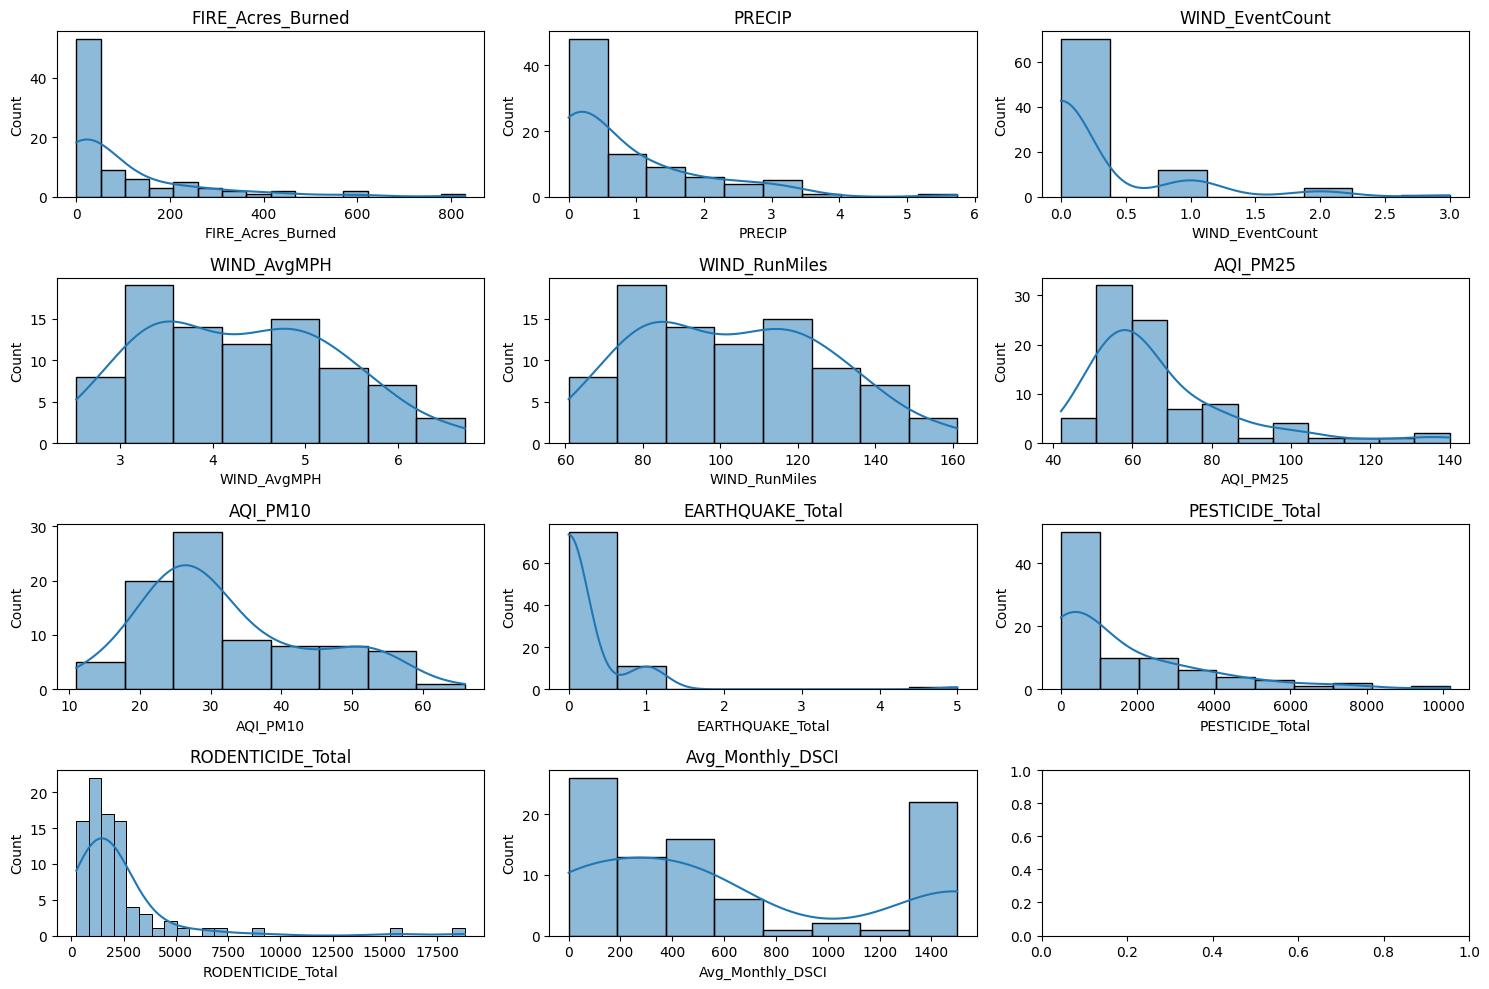

In [3]:
# VFRate is the target variable, YEAR_MONTH is time, so everything else is a feature.
# plot the histogram of all feature variables in a subplot
feature_cols = [col for col in df.columns if col not in ['YEAR_MONTH', 'VFRate']]
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

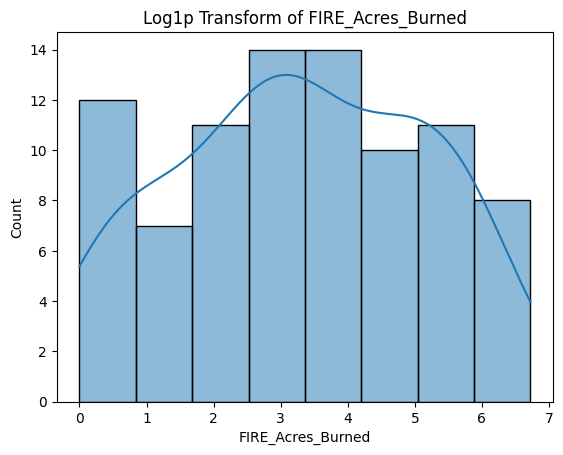

In [4]:
# FIRE_Acres_Burned is right skewed, plot the log1p transform as a histogram
sns.histplot(np.log1p(df['FIRE_Acres_Burned']), kde=True)
plt.title('Log1p Transform of FIRE_Acres_Burned')
plt.show()

In [5]:
# shpiro test for normality on the log1p transform of FIRE_Acres_Burned
stat, p = shapiro(np.log1p(df['FIRE_Acres_Burned']))
print('Shapiro-Wilk Test: Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample looks Gaussian (fail to reject H0)')
else:    print('Sample does not look Gaussian (reject H0)') 

Shapiro-Wilk Test: Statistics=0.966, p=0.021
Sample does not look Gaussian (reject H0)


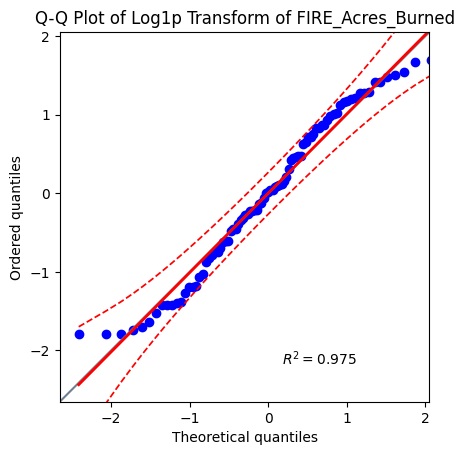

In [7]:
# try a Q-Q plot with pingouin as pg 
import pingouin as pg
pg.qqplot(np.log1p(df['FIRE_Acres_Burned']), dist='norm', confidence=0.95)
plt.title('Q-Q Plot of Log1p Transform of FIRE_Acres_Burned')
plt.show()


Analyzing PRECIP...


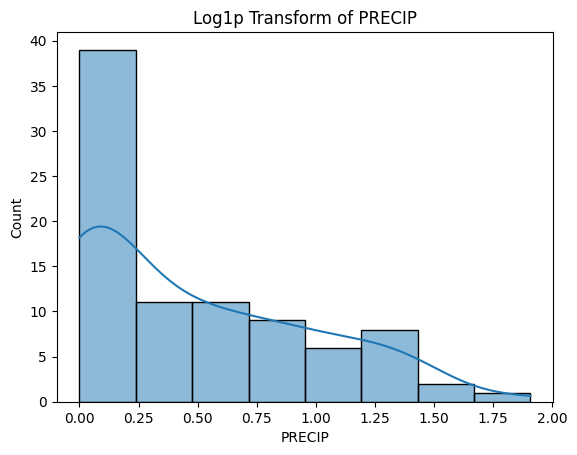

Shapiro-Wilk Test: Statistics=0.874, p=0.000
Sample does not look Gaussian (reject H0)


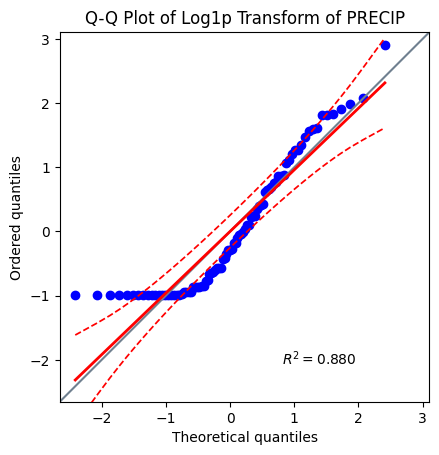

Analyzing PESTICIDE_Total...


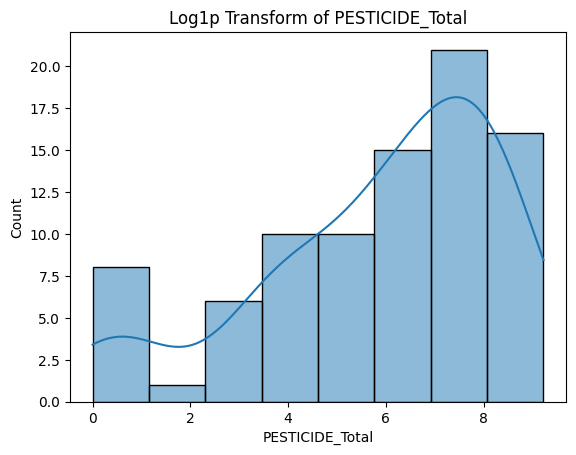

Shapiro-Wilk Test: Statistics=0.901, p=0.000
Sample does not look Gaussian (reject H0)


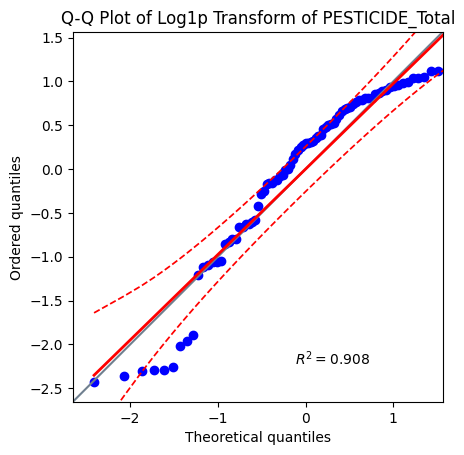

Analyzing RODENTICIDE_Total...


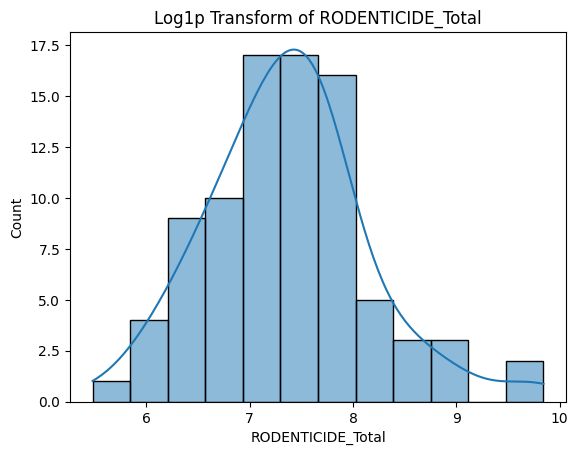

Shapiro-Wilk Test: Statistics=0.974, p=0.082
Sample looks Gaussian (fail to reject H0)


In [9]:
# check the other right skewed variables and try log1p and shapiro. If shapiro fails, try QQ plot
right_skewed_cols = ['PRECIP', 'PESTICIDE_Total', 'RODENTICIDE_Total']
for col in right_skewed_cols:
    print(f'Analyzing {col}...')
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f'Log1p Transform of {col}')
    plt.show()
    
    stat, p = shapiro(np.log1p(df[col]))
    print('Shapiro-Wilk Test: Statistics=%.3f, p=%.3f' % (stat, p))
    if p > 0.05:
        print('Sample looks Gaussian (fail to reject H0)')
    else:    
        print('Sample does not look Gaussian (reject H0)') 
        pg.qqplot(np.log1p(df[col]), dist='norm', confidence=0.95)
        plt.title(f'Q-Q Plot of Log1p Transform of {col}')
        plt.show()

Analyzing PRECIP with Power Transform...


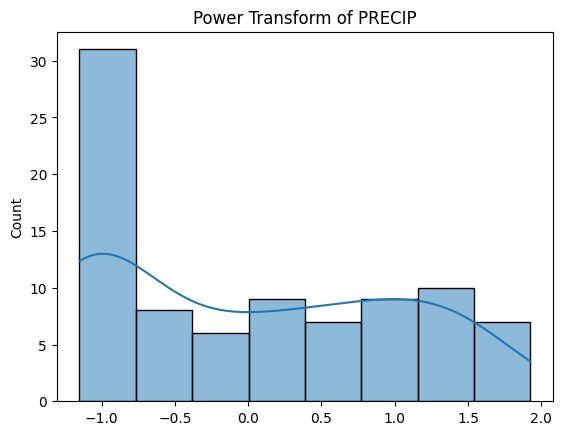

Shapiro-Wilk Test: Statistics=0.886, p=0.000
Sample does not look Gaussian (reject H0)


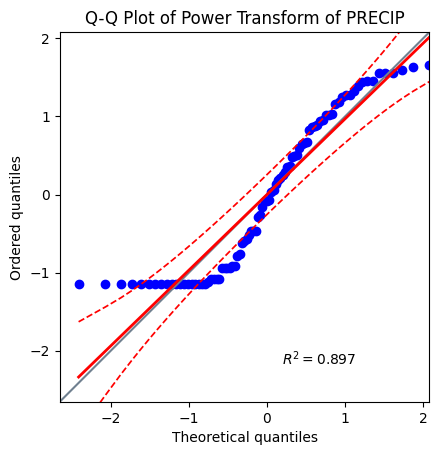

Analyzing PESTICIDE_Total with Power Transform...


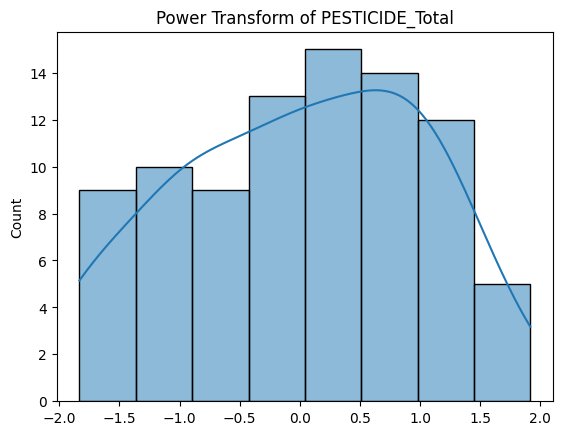

Shapiro-Wilk Test: Statistics=0.965, p=0.018
Sample does not look Gaussian (reject H0)


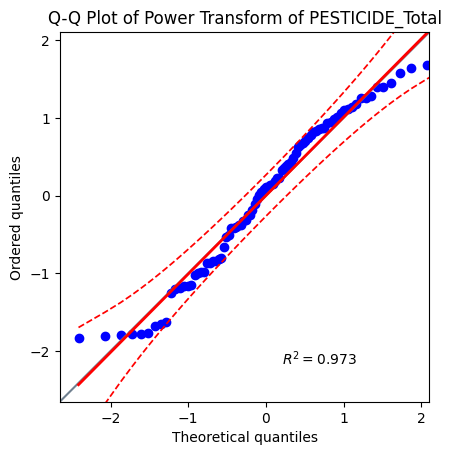

In [11]:
# whatever rejected H0 and had bad QQ try yeo-johnson power transform and shapiro again. If shapiro fails, try QQ plot
# RODENTICIDE is the only one we need to skip 
for col in ['PRECIP', 'PESTICIDE_Total']:
    print(f'Analyzing {col} with Power Transform...')
    pt = PowerTransformer(method='yeo-johnson')
    transformed_data = pt.fit_transform(df[[col]])
    
    sns.histplot(transformed_data.flatten(), kde=True)
    plt.title(f'Power Transform of {col}')
    plt.show()
    
    stat, p = shapiro(transformed_data.flatten())
    print('Shapiro-Wilk Test: Statistics=%.3f, p=%.3f' % (stat, p))
    if p > 0.05:
        print('Sample looks Gaussian (fail to reject H0)')
    else:    
        print('Sample does not look Gaussian (reject H0)') 
        pg.qqplot(transformed_data.flatten(), dist='norm', confidence=0.95)
        plt.title(f'Q-Q Plot of Power Transform of {col}')
        plt.show()

Analyzing PRECIP with Log1p and Power Transform...


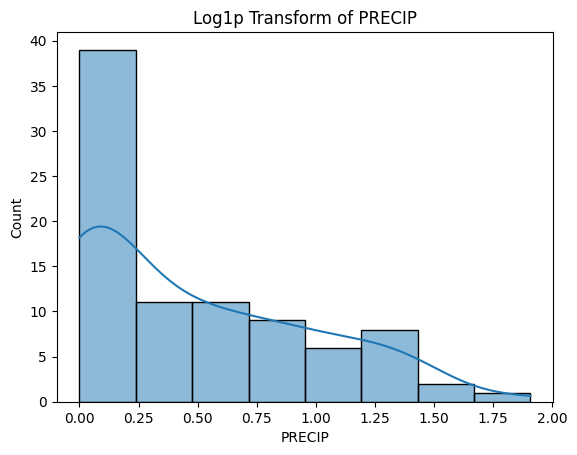

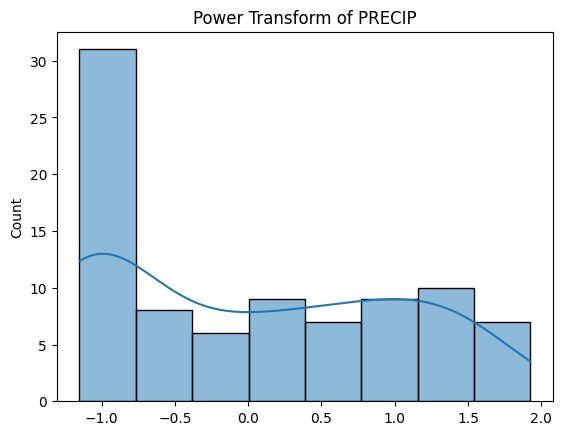

In [13]:
# need to figure out something for precip, log1p and yeo-johnson both fail 
bad_col = ['PRECIP']
for col in bad_col:
    print(f'Analyzing {col} with Log1p and Power Transform...')
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f'Log1p Transform of {col}')
    plt.show()
    
    pt = PowerTransformer(method='yeo-johnson')
    transformed_data = pt.fit_transform(df[[col]])
    
    sns.histplot(transformed_data.flatten(), kde=True)
    plt.title(f'Power Transform of {col}')
    plt.show()

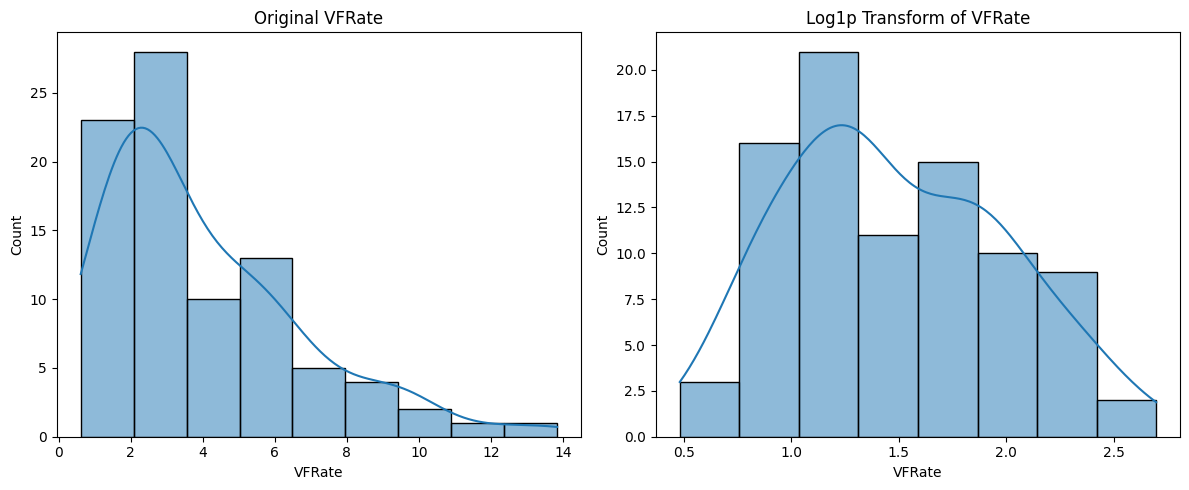

Shapiro-Wilk Test: Statistics=0.976, p=0.106
Sample looks Gaussian (fail to reject H0)


In [20]:
# try log1p of VFRate and do shapiro wilk with a side by side of pre-transformed VFRate
# use subplots to show both histograms side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.histplot(df['VFRate'], ax=axes[0], kde=True)
axes[0].set_title('Original VFRate')
sns.histplot(np.log1p(df['VFRate']), ax=axes[1], kde=True)
axes[1].set_title('Log1p Transform of VFRate')
plt.tight_layout()
plt.show()  

stat, p = shapiro(np.log1p(df['VFRate']))
print('Shapiro-Wilk Test: Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample looks Gaussian (fail to reject H0)')
else:    print('Sample does not look Gaussian (reject H0)')
    

In [23]:
# okay so summarize our findings for Fresno County:
# 1. FIRE_Acres_Burned is right skewed, log1p transform looks 
#    better but still fails normality tests, so we will use the log1p 
#    transform for modeling but note that it is not perfectly normal 
#    but QQ plot is fine
# 2. PRECIP is right skewed, log1p and power transform both fail 
#    normality tests, so we will keep it as is for modeling but 
#    note that it is not normal and has a long right tail
# 3. PESTICIDE_Total is right skewed but QQ plot for yeo-johnson power 
#    transform looks good, so we will use the power transform 
#    for modeling but note that it is not perfectly normal but QQ plot is fine
# 4. RODENTICIDE_Total is right skewed but log1p works well and 
#    passes normality tests, so we will use the log1p transform 
#   for modeling and note that it is approximately normal

# okay so now you will make a new dataframe for the transformed features,
# fire is replaced with log1p fire, precip is unchanged
# pesticide is replaced with power transform pesticide, and 
# rodenticide is replaced with log1p rodenticide
# replace the column name with log1pFEAT or YJFeat 
df_transformed = df.copy()
df_transformed['FIRE_Acres_Burned'] = np.log1p(df['FIRE_Acres_Burned'])
df_transformed['PESTICIDE_Total'] = PowerTransformer(method='yeo-johnson').fit_transform(df[['PESTICIDE_Total']])
df_transformed['RODENTICIDE_Total'] = np.log1p(df['RODENTICIDE_Total'])
df_transformed.rename(columns={
    'FIRE_Acres_Burned': 'log1p_FIRE_Acres_Burned',
    'PESTICIDE_Total': 'YJ_PESTICIDE_Total',
    'RODENTICIDE_Total': 'log1p_RODENTICIDE_Total'
}, inplace=True)  
df_transformed.head()


,YEAR_MONTH,VFRate,log1p_FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,YJ_PESTICIDE_Total,log1p_RODENTICIDE_Total,Avg_Monthly_DSCI,PRECIP_PowerTrans
0,2008-10-01,6.156349,5.105400,0.18,0.0,3.667742,87.825806,70.0,53.0,0,-1.200562,6.663622,515.4225,-0.590811
1,2008-11-01,3.407979,2.906901,1.49,0.0,3.106667,74.490000,95.5,38.5,0,-1.770579,6.247420,501.6900,1.028173
2,2008-12-01,6.486154,0.000000,1.19,0.0,3.306452,79.312903,94.0,18.5,0,-1.832881,5.479670,501.5300,0.830431
3,2009-01-01,6.619800,0.693147,1.25,0.0,2.587097,62.019355,102.0,33.0,0,-1.183483,5.981911,502.2950,0.874260
4,2009-02-01,5.751629,3.367296,2.33,0.0,3.928571,94.096429,51.5,13.0,0,-0.870375,5.929931,501.9950,1.390173


In [25]:
# drop the index and save this pdf as fresno_agg_drought_feattransformed.csv
df_transformed.to_csv('../../data/fresno_agg_drought_feattransformed.csv', index=False) 

In [27]:
# make another dataframe which is a copy of df_transformed but now 
# we also log1p VFRate and change name to log1pVFRate
df_transformed_vfrate = df_transformed.copy()
df_transformed_vfrate['VFRate'] = np.log1p(df['VFRate'])
df_transformed_vfrate.rename(columns={'VFRate': 'log1pVFRate'}, inplace=True)
df_transformed_vfrate.head()  

# save this as fresno_agg_drought_feattransformed_vfrate.csv
df_transformed_vfrate.to_csv('../../data/fresno_agg_drought_feattransformed_vfrate.csv', index=False) 

## Kern County Data

In [28]:
# grab the baseline kern county data
kern_df = pd.read_csv('../../data/kern_agg_drought_baseline.csv')
kern_df.head()

,YEAR_MONTH,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,RODENTICIDE_Total,Avg_Monthly_DSCI
0,2008-10-01,6.476629,0.0,0.04,0.0,3.483871,83.348387,78.0,76.0,0,1392.455039,689.3538,596.415
1,2008-11-01,6.110027,0.0,1.46,0.0,2.956667,70.930000,131.5,63.5,0,682.323659,341.5625,600.000
2,2008-12-01,5.499024,0.0,1.70,0.0,3.080645,73.777419,97.0,44.0,1,724.679851,461.0845,600.000
3,2009-01-01,3.734323,0.0,0.88,0.0,2.935484,70.329032,142.0,39.0,0,215.008252,257.3125,599.820
4,2009-02-01,3.975247,0.0,1.18,0.0,3.842857,92.107143,64.0,19.0,0,209.886979,133.2500,598.035


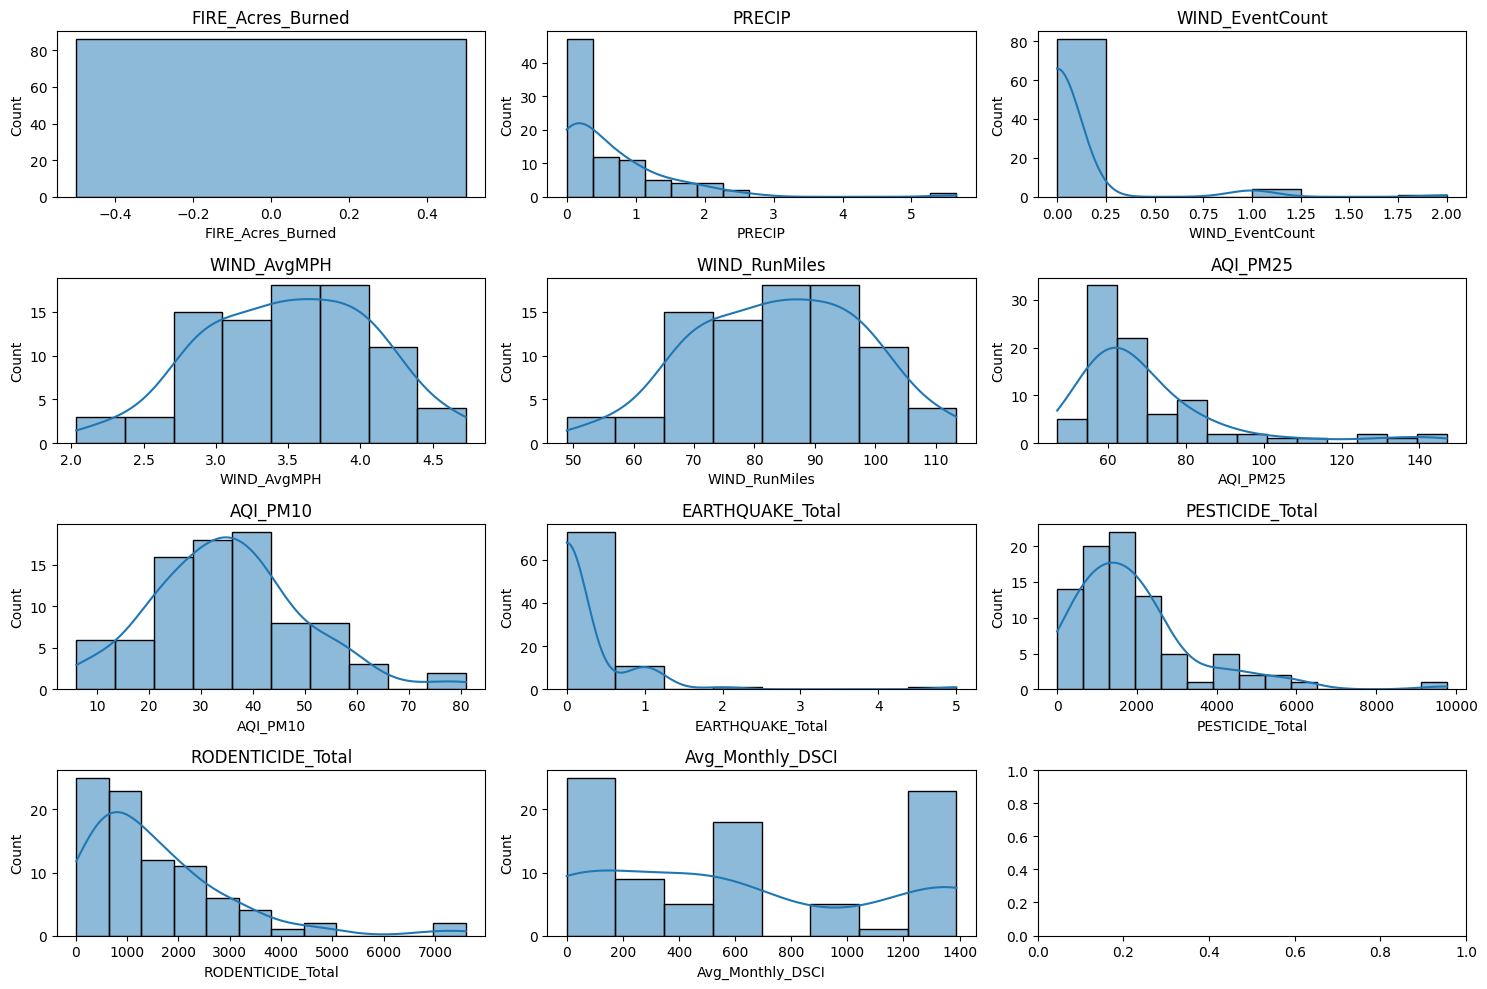

In [29]:
# subplot of all features in kern_df except YEAR_MONTH and VFRate
feature_cols_kern = [col for col in kern_df.columns if col not in ['YEAR_MONTH', 'VFRate']]
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols_kern):
    sns.histplot(kern_df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [30]:
# Drop FIRE_Acres_Burned 
kern_df.drop(columns=['FIRE_Acres_Burned'], inplace=True)
kern_df.head()  

,YEAR_MONTH,VFRate,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,RODENTICIDE_Total,Avg_Monthly_DSCI
0,2008-10-01,6.476629,0.04,0.0,3.483871,83.348387,78.0,76.0,0,1392.455039,689.3538,596.415
1,2008-11-01,6.110027,1.46,0.0,2.956667,70.930000,131.5,63.5,0,682.323659,341.5625,600.000
2,2008-12-01,5.499024,1.70,0.0,3.080645,73.777419,97.0,44.0,1,724.679851,461.0845,600.000
3,2009-01-01,3.734323,0.88,0.0,2.935484,70.329032,142.0,39.0,0,215.008252,257.3125,599.820
4,2009-02-01,3.975247,1.18,0.0,3.842857,92.107143,64.0,19.0,0,209.886979,133.2500,598.035


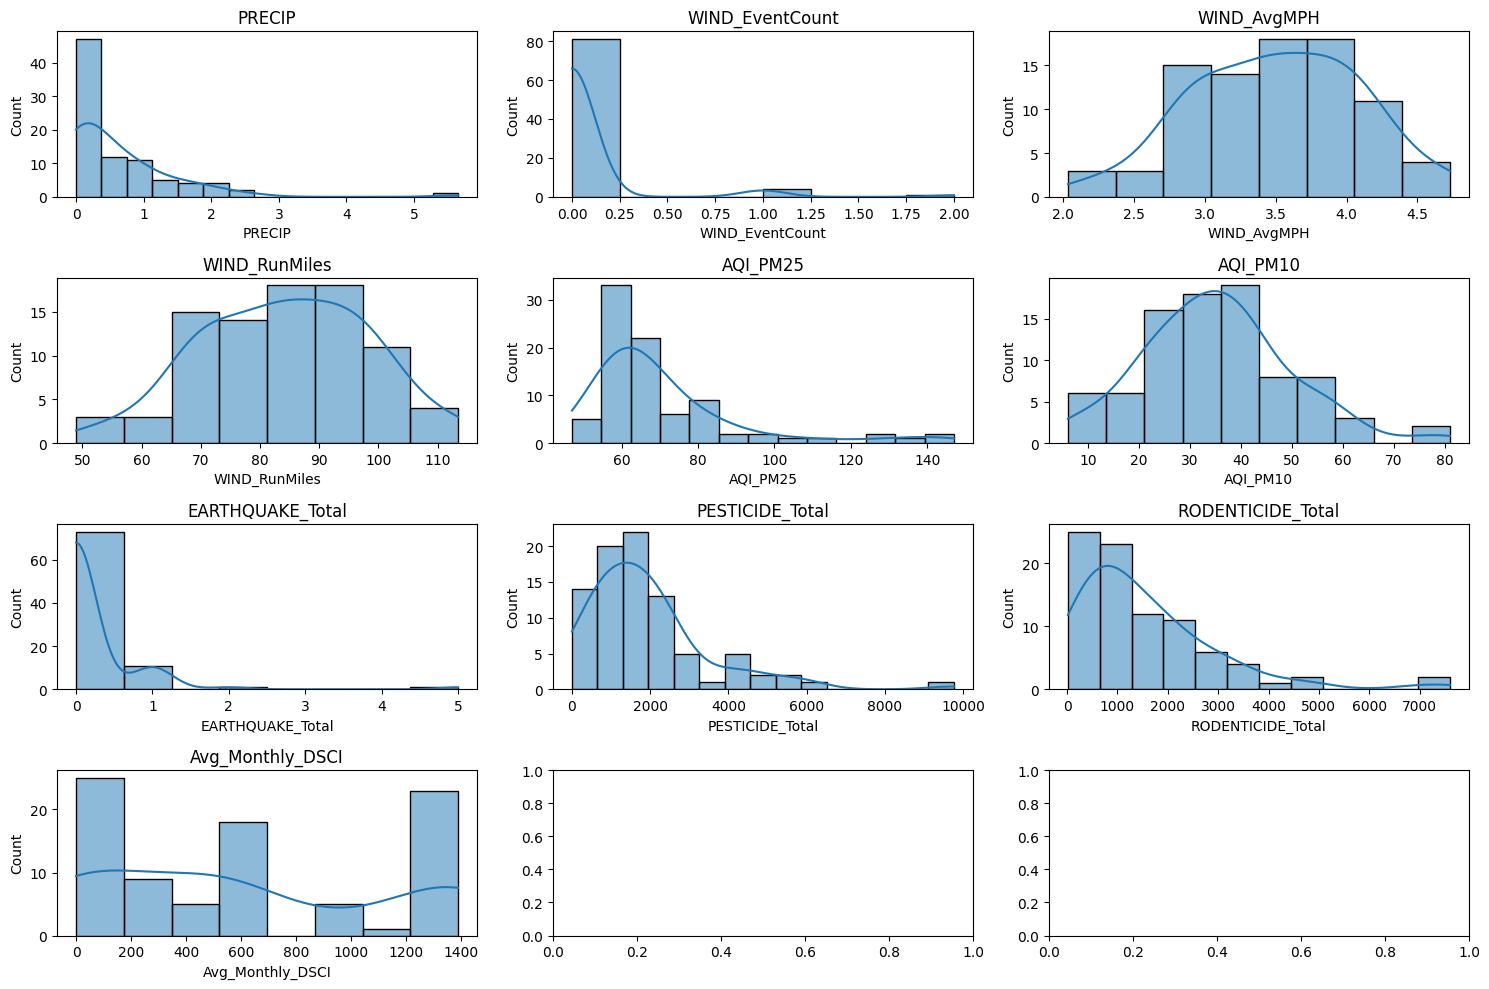

In [31]:
# Do another subplot side by side of features
feature_cols_kern = [col for col in kern_df.columns if col not in ['YEAR_MONTH', 'VFRate']]
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(feature_cols_kern):
    sns.histplot(kern_df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

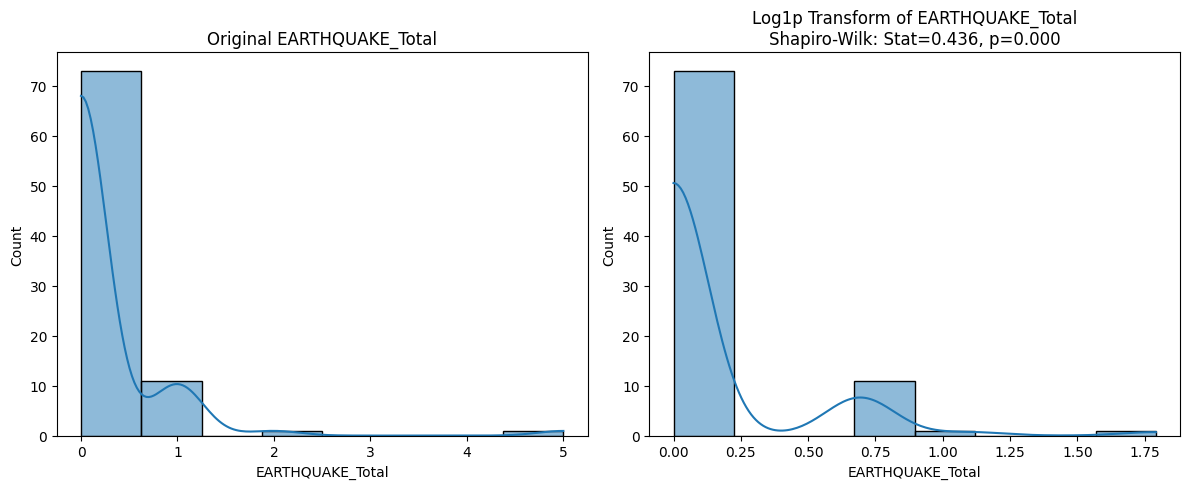

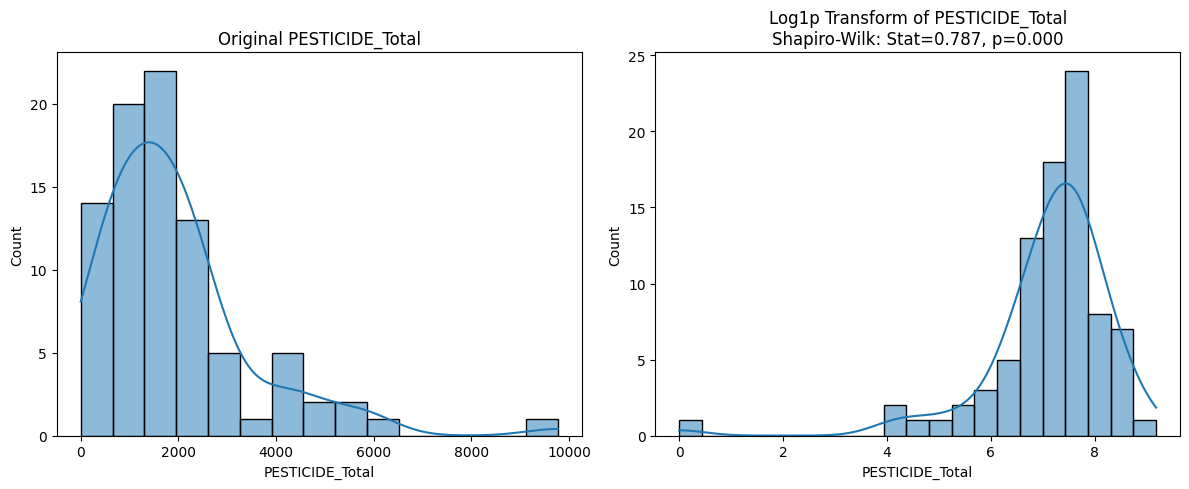

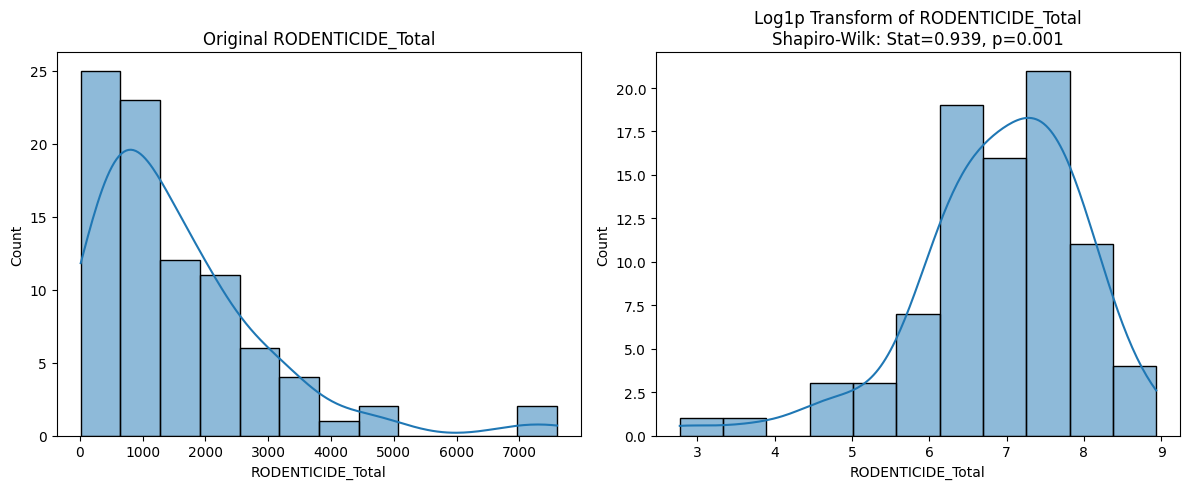

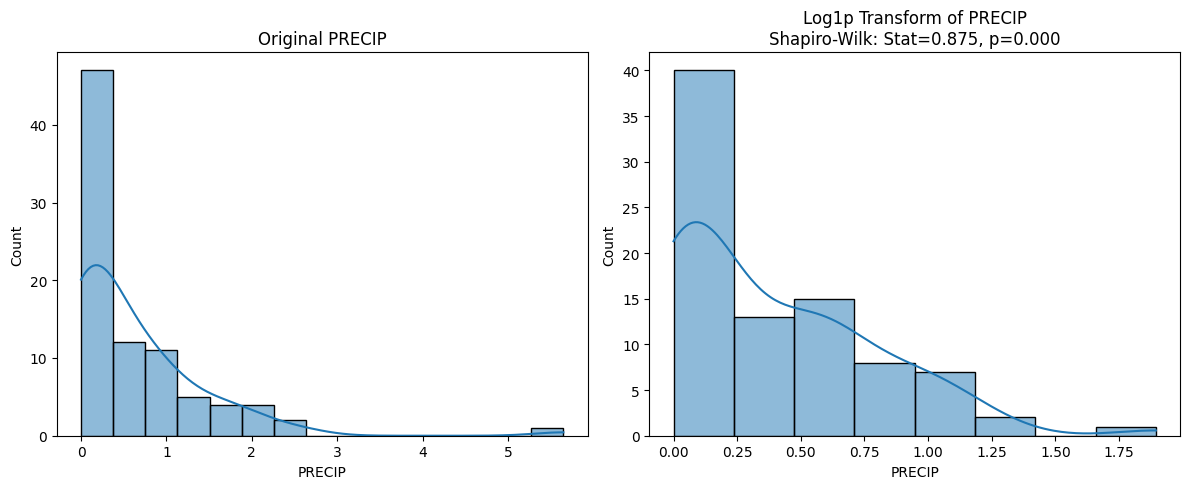

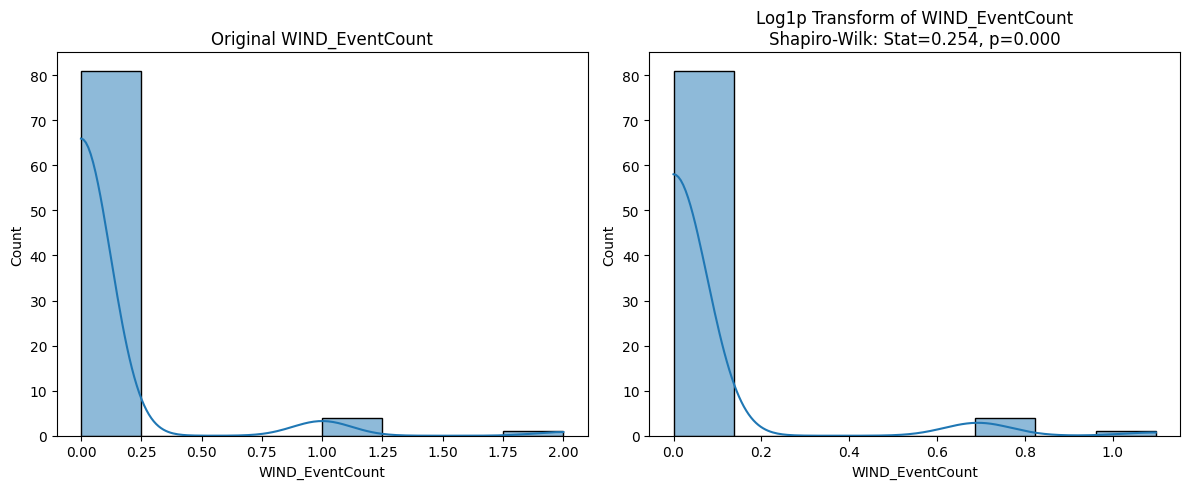

In [35]:
# try log1p for earthquake, pesticide, rodenticide, precip, and wind_eventcount 
# plot as subplot of histograms with log1p transform and original side by side for each feature
# and place the shapuro wilk test results in the title of the log1p histogram
for col in ['EARTHQUAKE_Total', 'PESTICIDE_Total', 'RODENTICIDE_Total', 'PRECIP', 'WIND_EventCount']:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.histplot(kern_df[col], ax=axes[0], kde=True)
    axes[0].set_title(f'Original {col}')
    
    log1p_data = np.log1p(kern_df[col])
    sns.histplot(log1p_data, ax=axes[1], kde=True)
    
    stat, p = shapiro(log1p_data)
    title = f'Log1p Transform of {col}\nShapiro-Wilk: Stat={stat:.3f}, p={p:.3f}'
    axes[1].set_title(title)
    
    plt.tight_layout()
    plt.show()



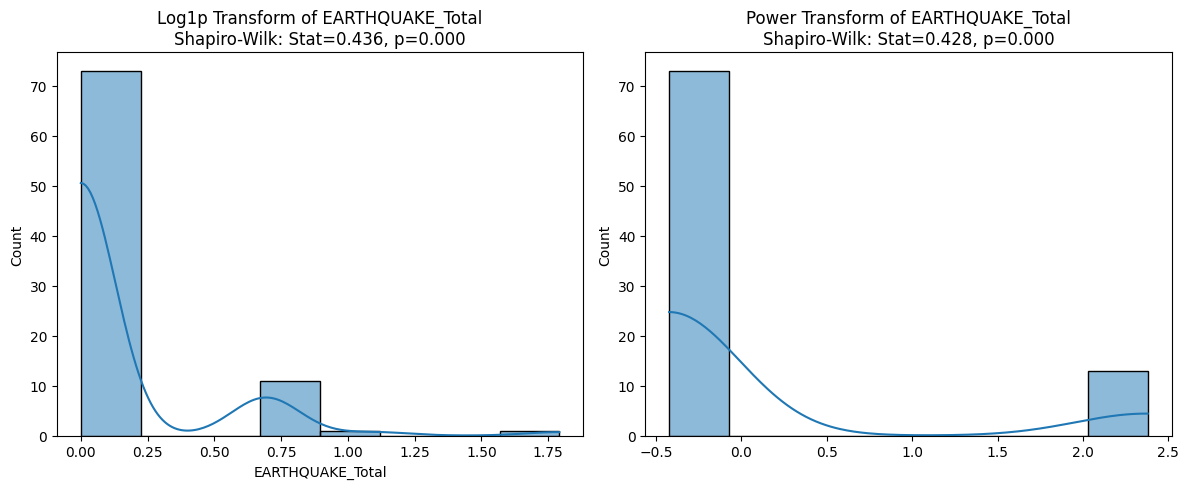

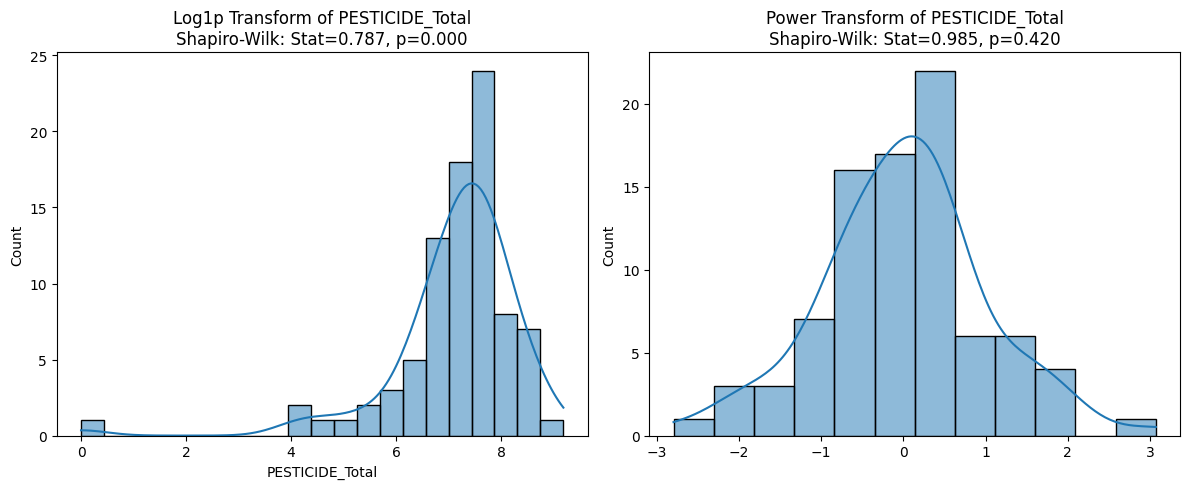

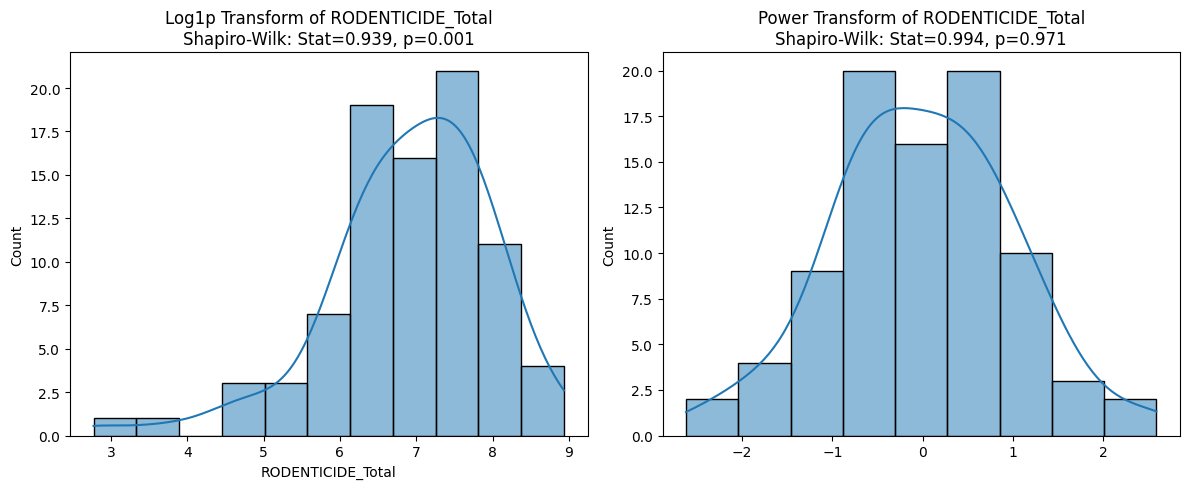

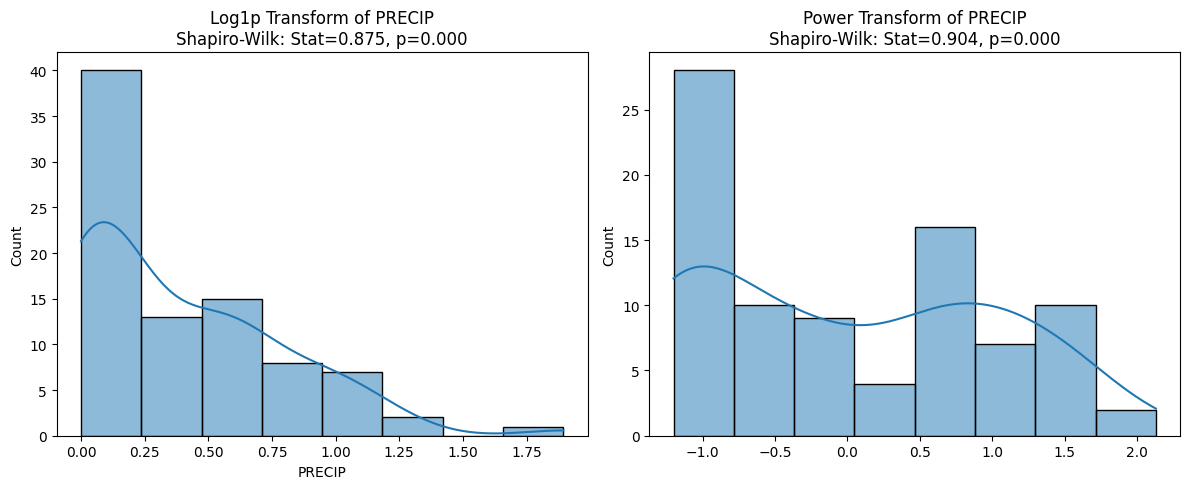

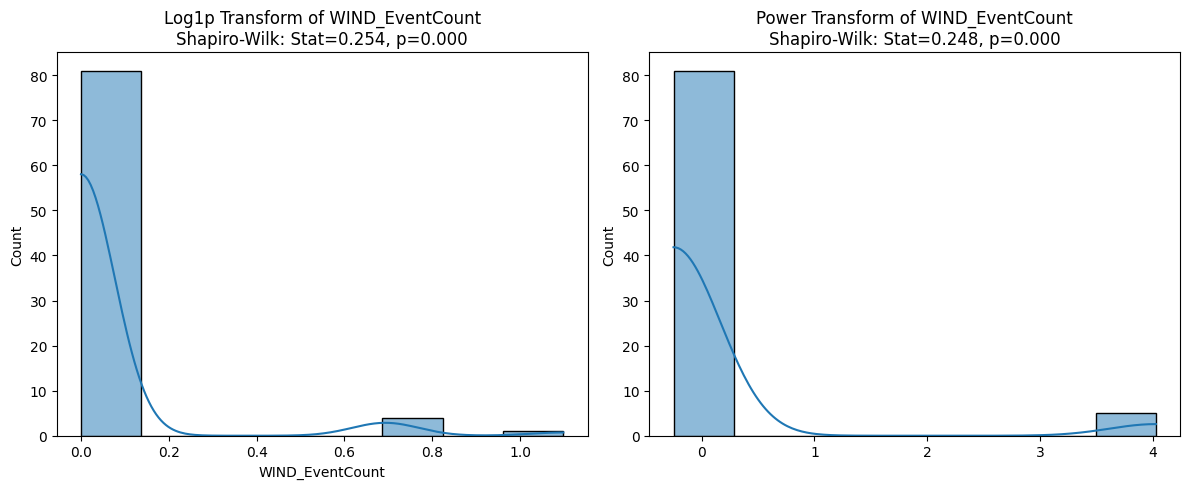

In [ ]:
# Do log1p and yeo-johnson for these features 
# plot the QQ plot using pg.qqplot for both the log1p and power transform
# as subplots side by side for each feature 
for col in ['EARTHQUAKE_Total', 'PESTICIDE_Total', 'RODENTICIDE_Total', 'PRECIP', 'WIND_EventCount']:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    
    # Log1p transform
    log1p_data = np.log1p(kern_df[col])
    sns.histplot(log1p_data, ax=axes[0], kde=True)
    stat_log1p, p_log1p = shapiro(log1p_data)
    title_log1p = f'Log1p Transform of {col}\nShapiro-Wilk: Stat={stat_log1p:.3f}, p={p_log1p:.3f}'
    axes[0].set_title(title_log1p)
    
    # Power transform
    pt = PowerTransformer(method='yeo-johnson')
    power_data = pt.fit_transform(kern_df[[col]]).flatten()
    sns.histplot(power_data, ax=axes[1], kde=True)
    stat_power, p_power = shapiro(power_data)
    title_power = f'Power Transform of {col}\nShapiro-Wilk: Stat={stat_power:.3f}, p={p_power:.3f}'
    axes[1].set_title(title_power)
    
    plt.tight_layout()
    plt.show()


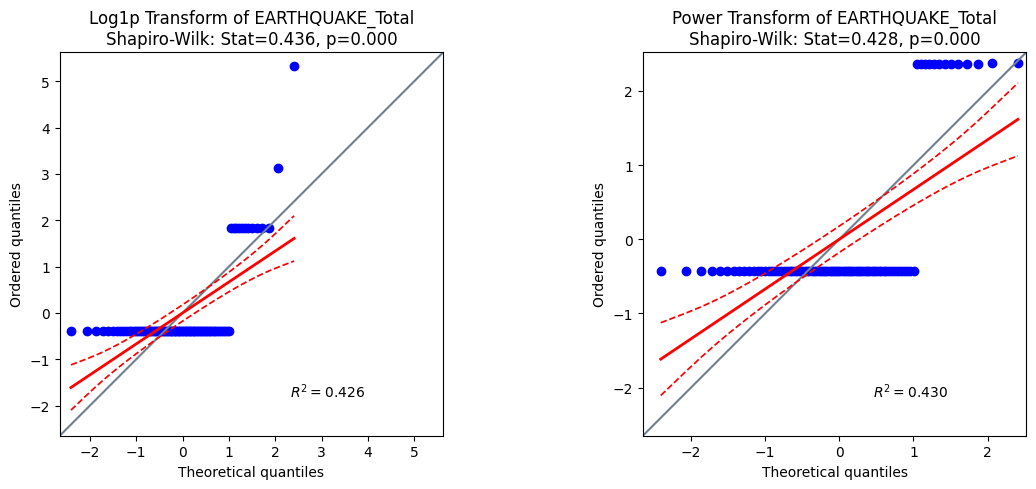

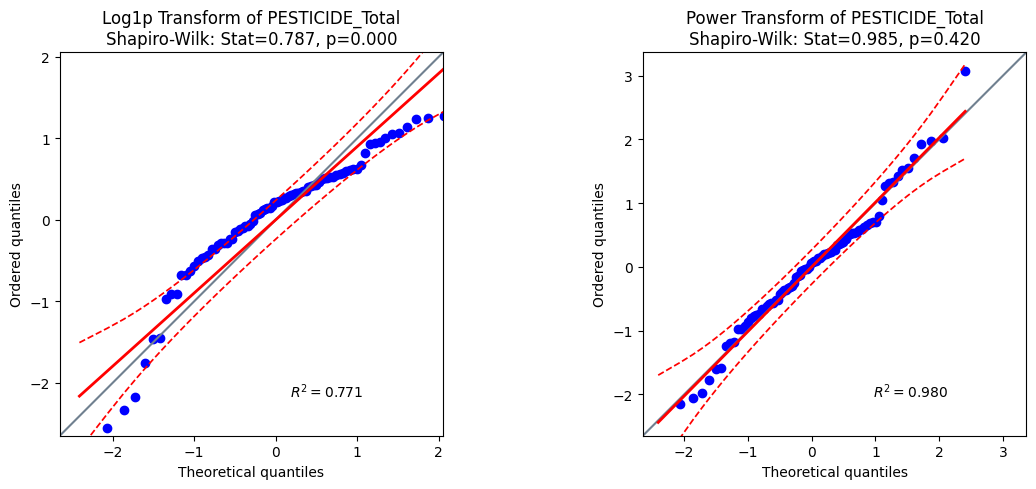

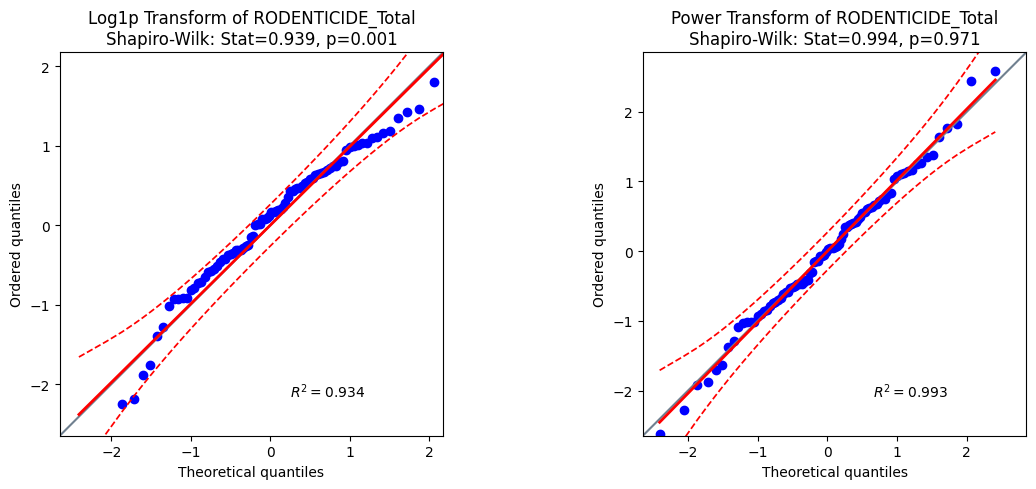

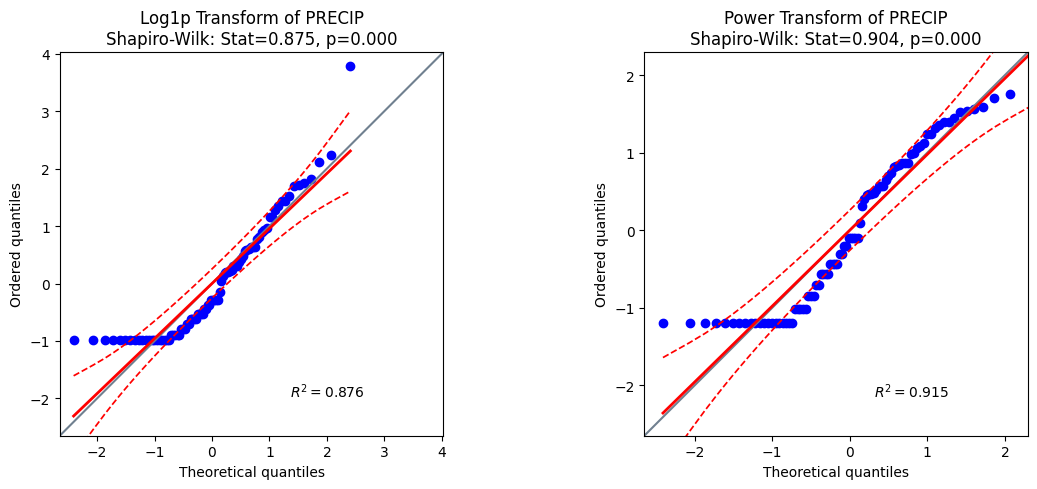

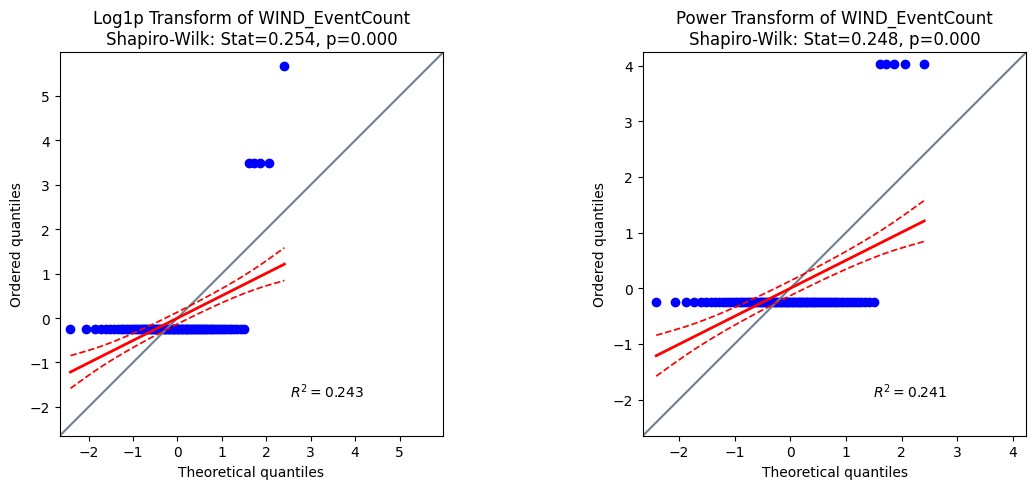

In [39]:
# now do subplot side by side QQplot for each feature with log1p and power transform using pg.qqplot
for col in ['EARTHQUAKE_Total', 'PESTICIDE_Total', 'RODENTICIDE_Total', 'PRECIP', 'WIND_EventCount']:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    
    # Log1p transform
    log1p_data = np.log1p(kern_df[col])
    pg.qqplot(log1p_data, dist='norm', confidence=0.95, ax=axes[0])
    stat_log1p, p_log1p = shapiro(log1p_data)
    title_log1p = f'Log1p Transform of {col}\nShapiro-Wilk: Stat={stat_log1p:.3f}, p={p_log1p:.3f}'
    axes[0].set_title(title_log1p)
    
    # Power transform
    pt = PowerTransformer(method='yeo-johnson')
    power_data = pt.fit_transform(kern_df[[col]]).flatten()
    pg.qqplot(power_data, dist='norm', confidence=0.95, ax=axes[1])
    stat_power, p_power = shapiro(power_data)
    title_power = f'Power Transform of {col}\nShapiro-Wilk: Stat={stat_power:.3f}, p={p_power:.3f}'
    axes[1].set_title(title_power)
    
    plt.tight_layout()
    plt.show()

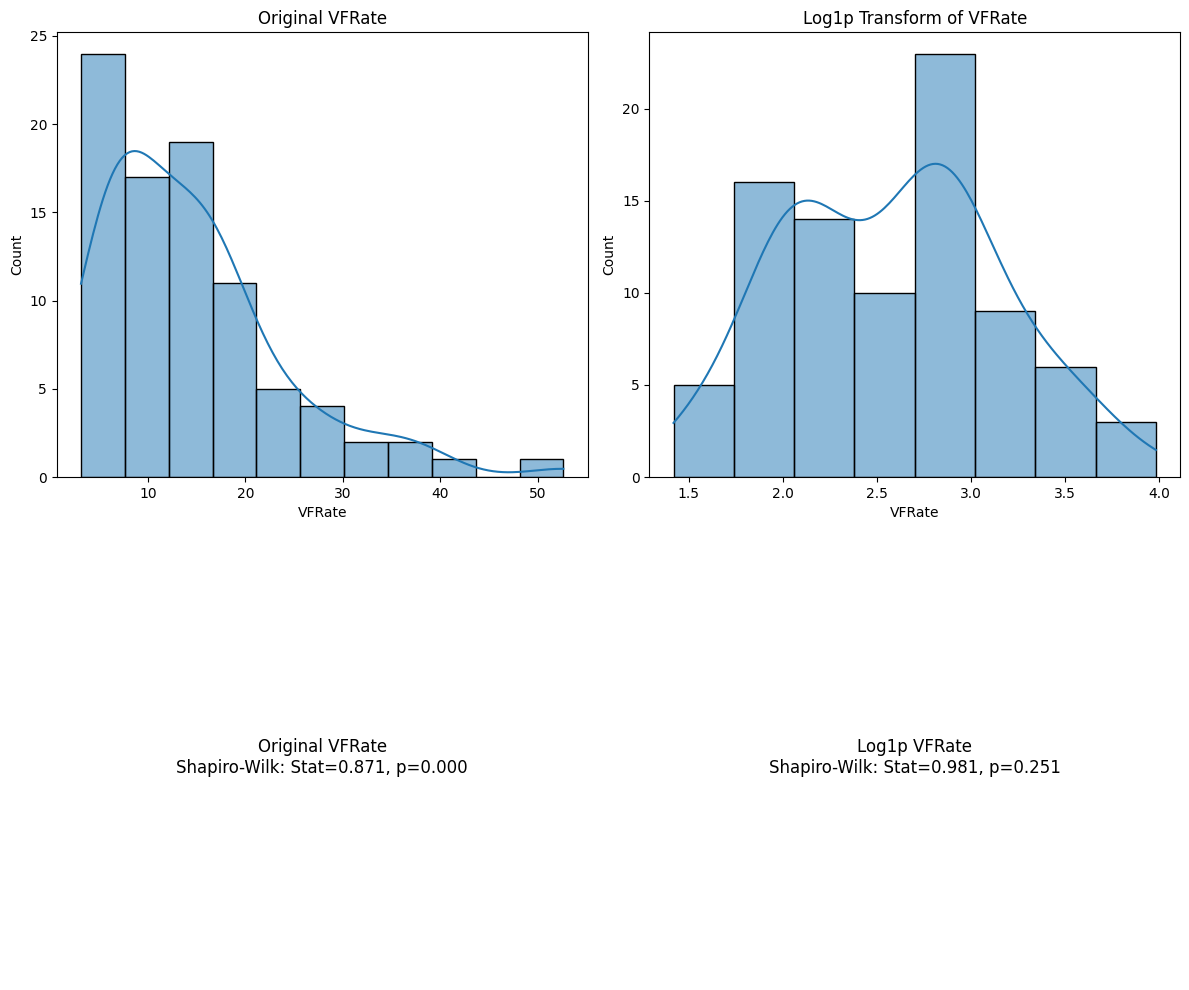

In [42]:
# now do shapiro of VFRate and log1pVFRate side by side with histograms and QQ plots for both
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(kern_df['VFRate'], ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Original VFRate')
sns.histplot(np.log1p(kern_df['VFRate']), ax=axes[0 , 1], kde=True)
axes[0, 1].set_title('Log1p Transform of VFRate') 
stat, p = shapiro(kern_df['VFRate'])
axes[1, 0].text(0.5, 0.5, f'Original VFRate\nShapiro-Wilk: Stat={stat:.3f}, p={p:.3f}', ha='center', va='center', fontsize=12)
axes[1, 0].axis('off')
stat_log1p, p_log1p = shapiro(np.log1p(kern_df['VFRate']))
axes[1, 1].text(0.5, 0.5, f'Log1p VFRate\nShapiro-Wilk: Stat={stat_log1p:.3f}, p={p_log1p:.3f}', ha='center', va='center', fontsize=12)
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [44]:
# Okay, summary time:
# 1. log1p for VFRate is good 
# 2. YJ of pesticide and rodenticide is good 
# no transforms for the other features in kern

In [45]:
# make a new dataframe with the transformed features in kern so VJ pesticide and
# rodenticide 
transformed_kern_df = kern_df.copy()
transformed_kern_df['PESTICIDE_Total'] = PowerTransformer(method='yeo-johnson').fit_transform(kern_df[['PESTICIDE_Total']])
transformed_kern_df['RODENTICIDE_Total'] = np.log1p(kern_df['RODENTICIDE_Total'])
transformed_kern_df.rename(columns={
    'PESTICIDE_Total': 'YJ_PESTICIDE_Total',
    'RODENTICIDE_Total': 'log1p_RODENTICIDE_Total'
}, inplace=True)
transformed_kern_df.head()


,YEAR_MONTH,VFRate,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,YJ_PESTICIDE_Total,log1p_RODENTICIDE_Total,Avg_Monthly_DSCI
0,2008-10-01,6.476629,0.04,0.0,3.483871,83.348387,78.0,76.0,0,-0.124170,6.537204,596.415
1,2008-11-01,6.110027,1.46,0.0,2.956667,70.930000,131.5,63.5,0,-0.809043,5.836454,600.000
2,2008-12-01,5.499024,1.70,0.0,3.080645,73.777419,97.0,44.0,1,-0.758253,6.135748,600.000
3,2009-01-01,3.734323,0.88,0.0,2.935484,70.329032,142.0,39.0,0,-1.584775,5.554170,599.820
4,2009-02-01,3.975247,1.18,0.0,3.842857,92.107143,64.0,19.0,0,-1.597544,4.899704,598.035


In [46]:
# save a new csv as kern_agg_drought_feattransformed.csv with the transformed features and log1pVFRate
transformed_kern_df.to_csv('../../data/kern_agg_drought_feattransformed.csv', index=False)

In [47]:
# make a new dataset with rodenticide and pesticide 
# transformed and log1pVFRate and save as 
# kern_agg_drought_feattransformed_vfrate.csv
transformed_kern_vfrate_df = transformed_kern_df.copy()
transformed_kern_vfrate_df['VFRate'] = np.log1p(kern_df['VFRate'])
transformed_kern_vfrate_df.rename(columns={'VFRate': 'log1pVFRate'}, inplace=True)
transformed_kern_vfrate_df.head() 
transformed_kern_vfrate_df.to_csv('../../data/kern_agg_drought_feattransformed_vfrate.csv', index=False)